In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
netflix_users_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Lesson14/netflix_users_data.csv')

In [ ]:
netflix_users_data

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month


Приведение столбцов к стилю camel_case

In [ ]:
import re

df = netflix_users_data.copy()

def to_camel_case(s):
    # убираем лишние символы (например пробелы и скобки)
    s = re.sub(r'[^\w\s]', '', s)

    # разбиваем по пробелам
    parts = s.split()

    # первое слово — с маленькой буквы
    parts[0] = parts[0].lower()

    # остальные — с большой буквы
    parts[1:] = [p.capitalize() for p in parts[1:]]

    return '_'.join(parts)

netflix_users_data.columns = [to_camel_case(col) for col in df.columns]

In [ ]:
netflix_users_data

,user_Id,subscription_Type,monthly_Revenue,join_Date,last_Payment_Date,country,age,gender,device,plan_Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month


Приведение типов данных

In [ ]:
import pandas as pd

df = netflix_users_data.copy()

df['join_Date'] = pd.to_datetime(
    df['join_Date'],
    format='%d-%m-%y',
    errors='coerce'
)

df['last_Payment_Date'] = pd.to_datetime(
    df['last_Payment_Date'],
    format='%d-%m-%y',
    errors='coerce'
)

In [ ]:
df

,user_Id,subscription_Type,monthly_Revenue,join_Date,last_Payment_Date,country,age,gender,device,plan_Duration
0,1,Basic,10,2022-01-15,2023-06-10,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,2021-09-05,2023-06-22,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,2023-02-28,2023-06-27,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,2022-07-10,2023-06-26,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,2023-05-01,2023-06-28,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,2022-07-25,2023-07-12,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,2022-08-04,2023-07-14,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,2022-08-09,2023-07-15,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,2022-08-12,2023-07-12,Canada,48,Female,Tablet,1 Month


Поиск дублей и пропусков в данных

In [ ]:
df.isna().sum()

,0
user_Id,0
subscription_Type,0
monthly_Revenue,0
join_Date,0
last_Payment_Date,0
country,0
age,0
gender,0
device,0
plan_Duration,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#Исследовательский анализ данных:

Количество уникальных пользователей и период, с которого появились эти пользователи?

In [ ]:
result = {
    "unique_users": netflix_users_data['user_Id'].nunique(),
    "period_start": netflix_users_data['join_Date'].min(),
    "period_end": netflix_users_data['join_Date'].max()
}

print(result)

{'unique_users': 2500, 'period_start': '01-03-22', 'period_end': '31-10-22'}


Возраст пользователей

In [ ]:
netflix_users_data['age'].describe()

,age
count,2500.000000
mean,38.795600
std,7.171778
min,26.000000
25%,32.000000
50%,39.000000
75%,45.000000
max,51.000000


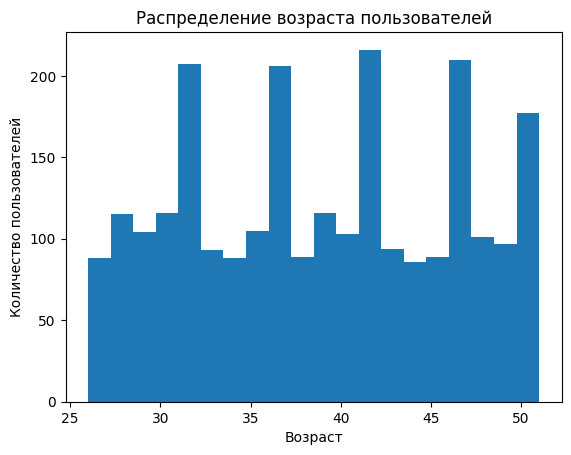

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(netflix_users_data['age'].dropna(), bins=20)
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.title('Распределение возраста пользователей')
plt.show()

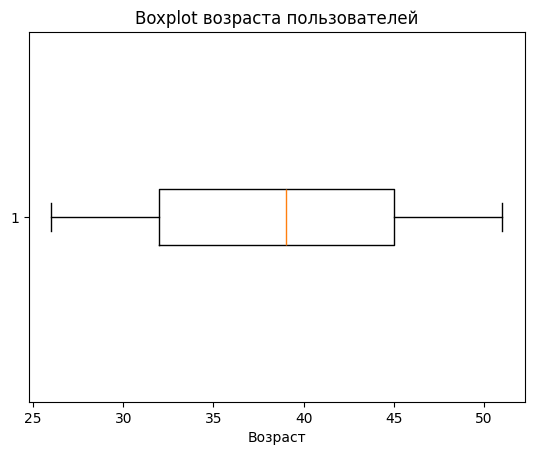

In [ ]:
plt.figure()
plt.boxplot(netflix_users_data['age'].dropna(), vert=False)
plt.xlabel('Возраст')
plt.title('Boxplot возраста пользователей')
plt.show()

Вывод: Распределение возраста пользователей показывает, что аудитория сервиса достаточно равномерно представлена в диапазоне примерно от 25 до 50 лет. пользователей среднего возраста. Основная масса пользователей сосредоточена в интервале примерно от 32 до 45 лет

Пол пользователей

In [ ]:
gender_counts = netflix_users_data['gender'].value_counts()
print(gender_counts)

gender
Female    1257
Male      1243
Name: count, dtype: int64


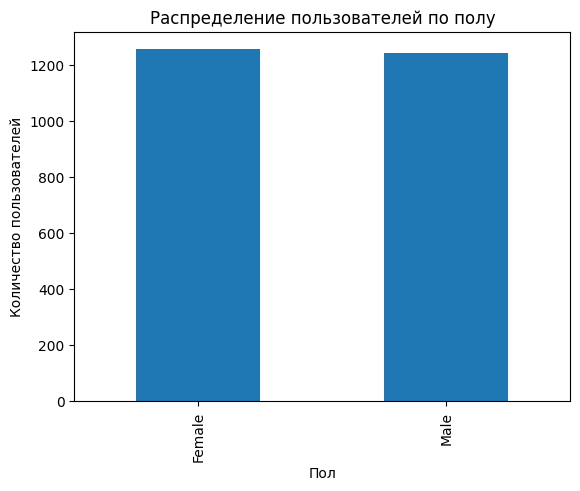

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
gender_counts.plot(kind='bar')
plt.xlabel('Пол')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по полу')
plt.show()

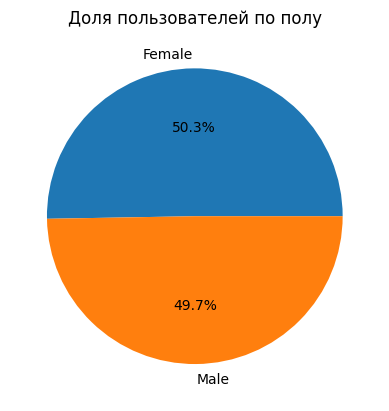

In [ ]:
plt.figure()
gender_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Доля пользователей по полу')
plt.show()

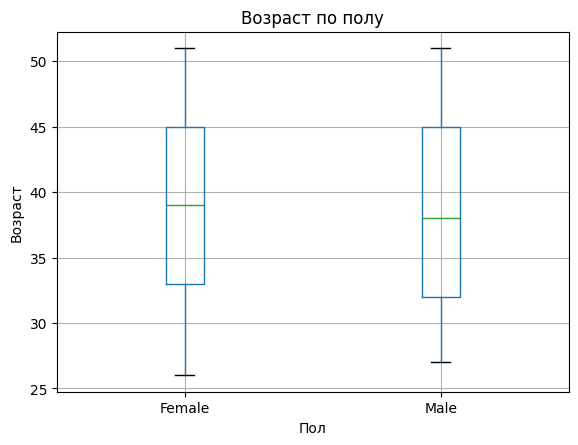

In [ ]:
import pandas as pd

netflix_users_data.boxplot(column='age', by='gender')
plt.title('Возраст по полу')
plt.suptitle('')
plt.xlabel('Пол')
plt.ylabel('Возраст')
plt.show()

Вывод: Распределение пользователей по полу практически равномерное: доля женщин составляет около 50.3%, а мужчин — 49.7%, что говорит об отсутствии гендерного перекоса в аудитории сервиса. Анализ возраста в разрезе пола показывает, что распределения у мужчин и женщин практически идентичны: медианный возраст находится на уровне около 38–40 лет, а основной диапазон значений (межквартильный размах) совпадает и лежит примерно в пределах 32–45 лет.

Девайсы пользователей

In [ ]:
device_counts = netflix_users_data['device'].value_counts()
print(device_counts)

device
Laptop        636
Tablet        633
Smartphone    621
Smart TV      610
Name: count, dtype: int64


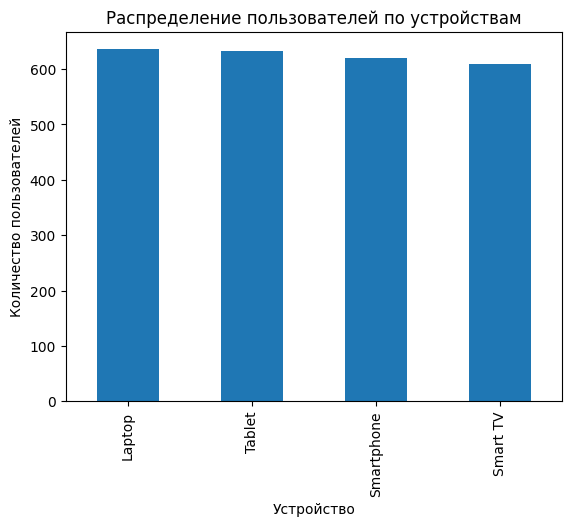

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
device_counts.plot(kind='bar')
plt.xlabel('Устройство')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по устройствам')
plt.show()

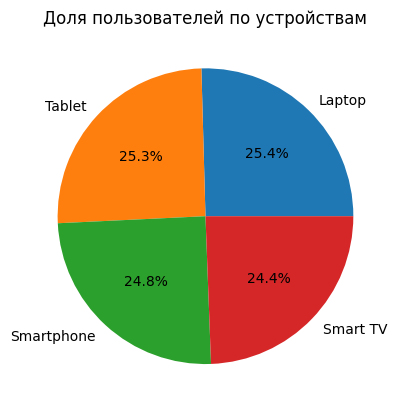

In [ ]:
plt.figure()
device_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Доля пользователей по устройствам')
plt.show()

Вывод: Распределение пользователей по устройствам показывает, что аудитория сервиса практически равномерно распределена между различными типами устройств. Наиболее популярным устройством является ноутбук, однако разница с другими категориями (планшеты, смартфоны и Smart TV) незначительна.

Тип подписки пользователей

In [ ]:
subscription_counts = netflix_users_data['subscription_Type'].value_counts()
print(subscription_counts)

subscription_Type
Basic       999
Standard    768
Premium     733
Name: count, dtype: int64


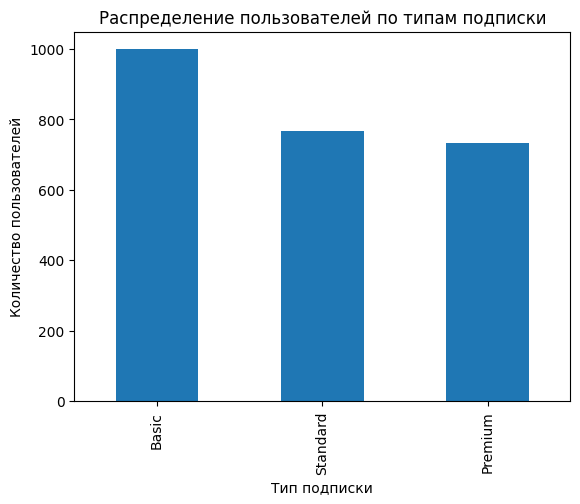

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
subscription_counts.plot(kind='bar')
plt.xlabel('Тип подписки')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по типам подписки')
plt.show()

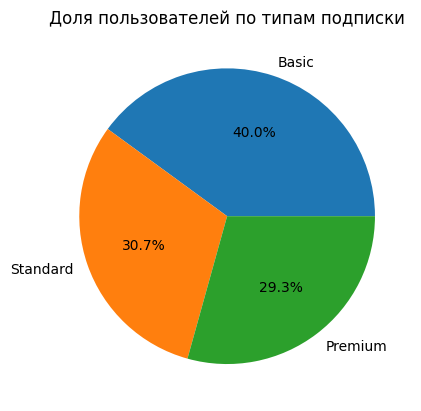

In [ ]:
plt.figure()
subscription_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Доля пользователей по типам подписки')
plt.show()

Вывод: Распределение пользователей по типам подписки показывает, что наиболее популярным тарифом является Basic, который выбирает наибольшее количество пользователей. Тарифы Standard и Premium имеют меньшую, но при этом достаточно близкую между собой аудиторию, при этом Standard немного опережает Premium.
Такая структура говорит о том, что большинство пользователей предпочитает более доступный базовый тариф, вероятно из-за его стоимости, в то время как более дорогие подписки выбирает меньшая часть аудитории.

Локация пользователей

In [ ]:
country_counts = netflix_users_data['country'].value_counts()
print(country_counts)

country
United States     451
Spain             451
Canada            317
United Kingdom    183
Germany           183
Australia         183
France            183
Brazil            183
Mexico            183
Italy             183
Name: count, dtype: int64


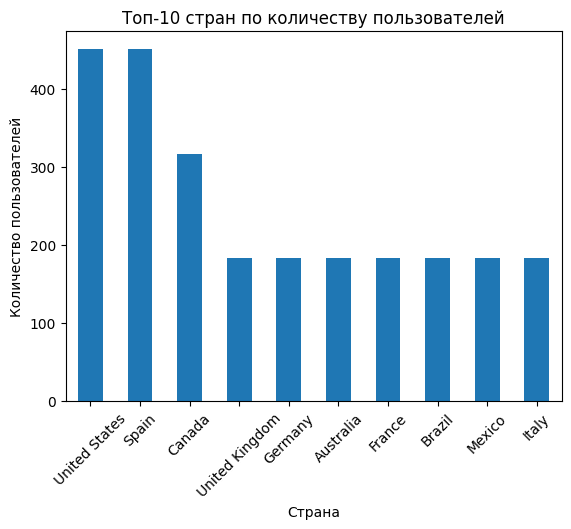

In [ ]:
import matplotlib.pyplot as plt

top_countries = country_counts.head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.xlabel('Страна')
plt.ylabel('Количество пользователей')
plt.title('Топ-10 стран по количеству пользователей')
plt.xticks(rotation=45)
plt.show()

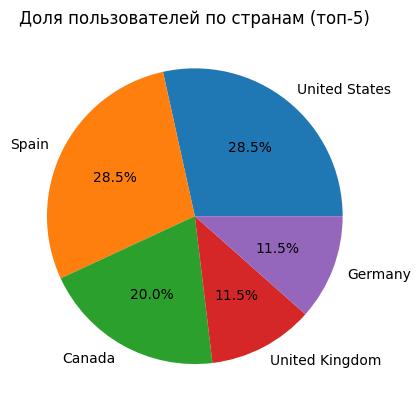

In [ ]:
plt.figure()
country_counts.head(5).plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Доля пользователей по странам (топ-5)')
plt.show()

Вывод: Распределение пользователей по странам показывает, что наибольшее количество пользователей сосредоточено в США и Испании, которые являются явными лидерами с примерно одинаковыми значениями. Далее с заметным отрывом следует Канада, после чего остальные страны (Великобритания, Германия, Австралия, Франция, Бразилия, Мексика и Италия) имеют примерно одинаковое и значительно меньшее количество пользователей.

Динамика привлечения пользователей

In [ ]:
netflix_users_data['join_Date'] = pd.to_datetime(netflix_users_data['join_Date'])

/tmp/ipykernel_1517/2017227867.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  netflix_users_data['join_Date'] = pd.to_datetime(netflix_users_data['join_Date'])


In [ ]:
users_by_month = netflix_users_data.groupby(
    netflix_users_data['join_Date'].dt.to_period('M')
).size()

In [ ]:
users_by_month.index = users_by_month.index.to_timestamp()

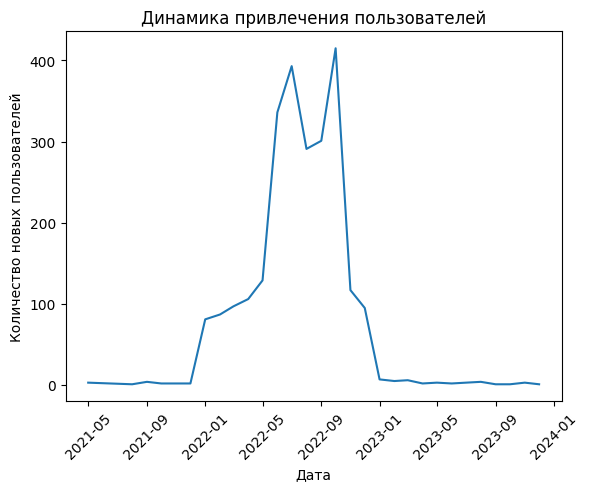

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(users_by_month.index, users_by_month.values)
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')
plt.title('Динамика привлечения пользователей')
plt.xticks(rotation=45)
plt.show()

Вывод: Динамика привлечения пользователей показывает, что на начальном этапе количество новых пользователей было крайне низким и практически отсутствовал рост. Начиная примерно с начала 2022 года наблюдается резкое увеличение притока пользователей, которое достигает пика в середине–конце 2022 года (около 400+ новых пользователей в месяц).
После достижения максимальных значений происходит столь же резкое снижение, и уже к началу 2023 года приток пользователей практически обнуляется и остаётся на низком уровне в дальнейшем периоде.
Таким образом, можно сделать вывод, что рост аудитории носил кратковременный характер с ярко выраженным пиковым периодом

Динамика выручки сервиса

In [ ]:
netflix_users_data['join_Date'] = pd.to_datetime(netflix_users_data['join_Date'])
netflix_users_data['last_Payment_Date'] = pd.to_datetime(netflix_users_data['last_Payment_Date'])

/tmp/ipykernel_1517/1870483625.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  netflix_users_data['last_Payment_Date'] = pd.to_datetime(netflix_users_data['last_Payment_Date'])


In [ ]:
netflix_users_data['months_active'] = (
    (netflix_users_data['last_Payment_Date'] - netflix_users_data['join_Date']) / pd.Timedelta(days=30)
).round().astype(int)

In [ ]:
netflix_users_data['months_active'] = netflix_users_data['months_active'].clip(lower=1)

In [ ]:
netflix_users_data['total_revenue'] = (
    netflix_users_data['months_active'] * netflix_users_data['monthly_Revenue']
)

In [ ]:
total_revenue = netflix_users_data['total_revenue'].sum()
print(total_revenue)

340311


In [ ]:
import pandas as pd

revenue_list = []

for _, row in netflix_users_data.iterrows():
    months = pd.date_range(start=row['join_Date'],
                           end=row['last_Payment_Date'],
                           freq='MS')

    for month in months:
        revenue_list.append({
            'date': month,
            'revenue': row['monthly_Revenue']
        })

revenue_df = pd.DataFrame(revenue_list)

In [ ]:
monthly_revenue = revenue_df.groupby('date')['revenue'].sum()

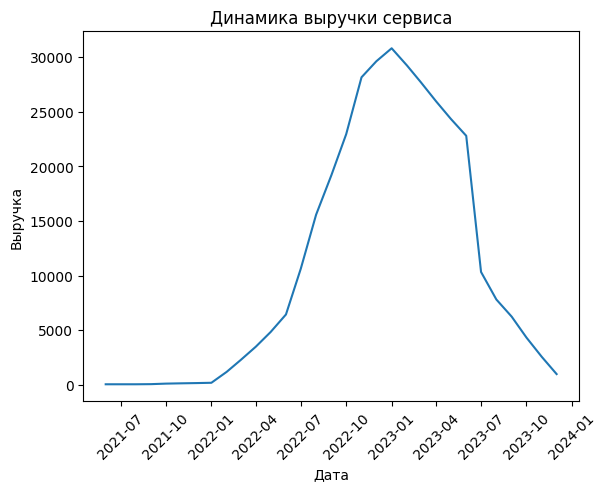

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.title('Динамика выручки сервиса')
plt.xticks(rotation=45)
plt.show()

Вывод: Динамика выручки сервиса показывает, что на начальном этапе доход практически отсутствовал, что соответствует низкому притоку пользователей в этот период. Начиная с середины 2022 года наблюдается резкий рост выручки, который обусловлен активным привлечением новых пользователей и накоплением платящей базы. Выручка достигает своего пика в конце 2022 — начале 2023 года, превышая 30 000, что отражает максимальное количество активных подписчиков.

После достижения пикового значения начинается постепенное, а затем и резкое снижение выручки, что связано с уменьшением притока новых пользователей и, вероятно, оттоком существующих. К концу рассматриваемого периода выручка существенно падает, практически возвращаясь к низким значениям.

Таким образом, можно сделать вывод, что сервис пережил краткосрочный период интенсивного роста с последующим спадом, что может свидетельствовать о временном эффекте (например, маркетинговой кампании или запуске продукта) без формирования устойчивой долгосрочной базы пользователей.

Разделяем клиентов на корзины по возрасту и определяем самую платежеспособную группу

In [ ]:
bins = [18, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '55+']

netflix_users_data['age_group'] = pd.cut(
    netflix_users_data['age'],
    bins=bins,
    labels=labels,
    right=True
)

In [ ]:
revenue_by_age = netflix_users_data.groupby('age_group')['total_revenue'].sum()
print(revenue_by_age)

age_group
18-25         0
26-35    127133
36-45    134964
46-55     78214
55+           0
Name: total_revenue, dtype: int64


/tmp/ipykernel_1517/3267630395.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age = netflix_users_data.groupby('age_group')['total_revenue'].sum()


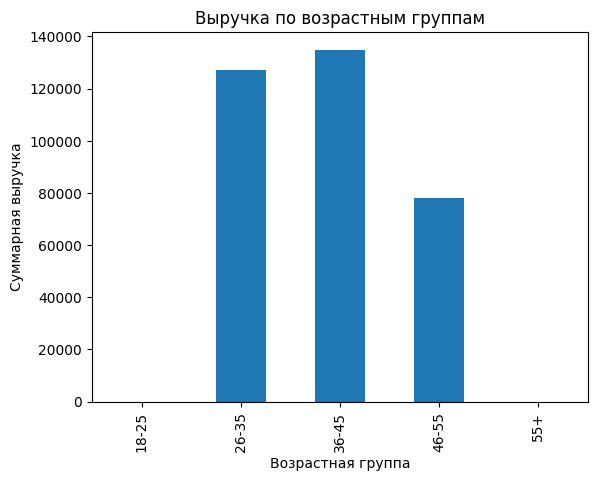

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
revenue_by_age.plot(kind='bar')
plt.xlabel('Возрастная группа')
plt.ylabel('Суммарная выручка')
plt.title('Выручка по возрастным группам')
plt.show()

Вывод: Анализ выручки по возрастным группам показывает, что наибольший вклад в общую выручку сервиса вносит группа пользователей 36–45 лет, которая является самой прибыльной. Немного уступает ей группа 26–35 лет, также демонстрируя высокий уровень суммарной выручки. Пользователи в возрасте 46–55 лет приносят заметно меньшую выручку, а группы 18–25 и 55+ практически не вносят вклад в общий доход.
Таким образом, можно сделать вывод, что основная платежеспособная аудитория сервиса сосредоточена в возрастном диапазоне от 26 до 45 лет.

Зависимость типа тарифа от группы возраста пользователя

In [ ]:
age_subscription = pd.crosstab(
    netflix_users_data['age_group'],
    netflix_users_data['subscription_Type']
)

print(age_subscription)

subscription_Type  Basic  Premium  Standard
age_group                                  
26-35                354      285       277
36-45                405      279       315
46-55                240      169       176


In [ ]:
age_subscription_ratio = age_subscription.div(age_subscription.sum(axis=1), axis=0)
print(age_subscription_ratio)

subscription_Type     Basic   Premium  Standard
age_group                                      
26-35              0.386463  0.311135  0.302402
36-45              0.405405  0.279279  0.315315
46-55              0.410256  0.288889  0.300855


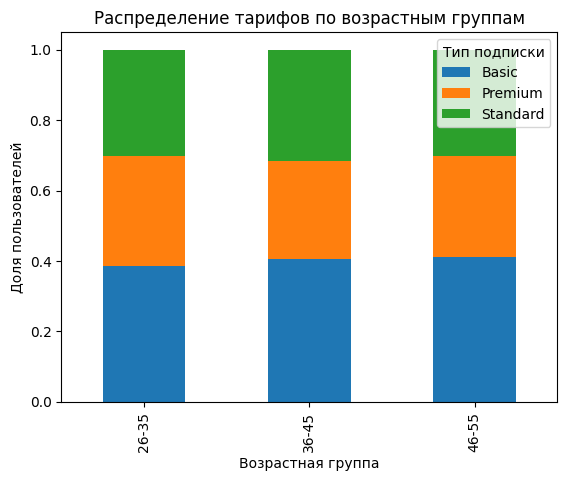

In [ ]:
import matplotlib.pyplot as plt

age_subscription_ratio.plot(kind='bar', stacked=True)
plt.xlabel('Возрастная группа')
plt.ylabel('Доля пользователей')
plt.title('Распределение тарифов по возрастным группам')
plt.legend(title='Тип подписки')
plt.show()

In [ ]:
premium_share = age_subscription_ratio['Premium'].sort_values(ascending=False)
print(premium_share)

age_group
26-35    0.311135
46-55    0.288889
36-45    0.279279
Name: Premium, dtype: float64


Вывод: Анализ распределения тарифов по возрастным группам показывает, что структура потребления подписок во всех группах в целом схожа: наибольшую долю занимает тариф Basic, затем следуют Premium и Standard с близкими значениями. Это говорит об отсутствии резких различий в предпочтениях пользователей разных возрастов.

Тем не менее, при более детальном рассмотрении доли премиум-подписки видно, что наибольшая доля пользователей с тарифом Premium наблюдается в группе 26–35 лет (около 31%), далее следует группа 46–55 лет (~29%), и наименьшая доля — в группе 36–45 лет (~28%).

Таким образом, можно сделать вывод, что наиболее платежеспособной с точки зрения выбора более дорогого тарифа является группа 26–35 лет, тогда как пользователи 36–45 лет, несмотря на высокий общий вклад в выручку, чаще выбирают более базовые тарифы. В целом различия между группами незначительны, что указывает на относительно равномерное распределение платежеспособности по возрастам.

Зависимость типа тарифа от страны пользователя

In [ ]:
country_subscription = pd.crosstab(
    netflix_users_data['country'],
    netflix_users_data['subscription_Type']
)

In [ ]:
country_subscription_ratio = country_subscription.div(
    country_subscription.sum(axis=1), axis=0
)

In [ ]:
top_countries = netflix_users_data['country'].value_counts().head(10).index

country_subscription_ratio_top = country_subscription_ratio.loc[top_countries]

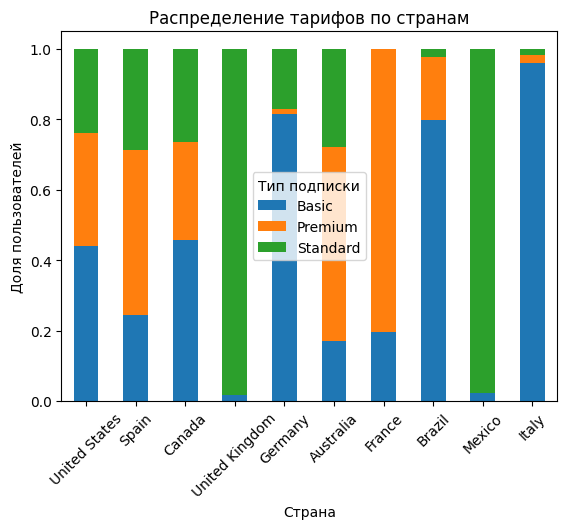

In [ ]:
import matplotlib.pyplot as plt

country_subscription_ratio_top.plot(kind='bar', stacked=True)
plt.xlabel('Страна')
plt.ylabel('Доля пользователей')
plt.title('Распределение тарифов по странам')
plt.legend(title='Тип подписки')
plt.xticks(rotation=45)
plt.show()

In [ ]:
premium_by_country = country_subscription_ratio['Premium'].sort_values(ascending=False)
print(premium_by_country.head(10))

country
France            0.803279
Australia         0.551913
Spain             0.470067
United States     0.321508
Canada            0.277603
Brazil            0.180328
Italy             0.021858
Germany           0.016393
Mexico            0.000000
United Kingdom    0.000000
Name: Premium, dtype: float64


Вывод: Анализ распределения тарифов по странам показывает, что зависимость между страной и типом подписки присутствует и в некоторых случаях выражена достаточно сильно. Наиболее ярко это видно во Франции, где доля пользователей с тарифом Premium является максимальной (около 80%), что делает этот рынок самым платежеспособным среди рассмотренных. Также высокая доля премиум-подписки наблюдается в Австралии (~55%) и в меньшей степени в Испании (~47%).
В то же время в ряде стран преобладают более дешёвые тарифы. Например, в Мексике и Великобритании практически отсутствуют пользователи с Premium-подпиской, а основная доля приходится на более доступные тарифы, особенно Standard. В Германии и Италии также наблюдается крайне низкая доля Premium, что может свидетельствовать о более высокой чувствительности пользователей к цене.
Такие различия позволяют сделать вывод, что платежеспособность аудитории существенно варьируется в зависимости от страны. Наиболее перспективными с точки зрения монетизации являются рынки Франции и Австралии, тогда как в других странах пользователи чаще выбирают более доступные тарифы.

Общий вывод:
Основные закономерности, выявленные в ходе анализа, показывают, что аудитория сервиса достаточно однородна по ключевым социально-демографическим характеристикам. Возраст пользователей распределён относительно равномерно в диапазоне от 25 до 50 лет, при этом основная масса сосредоточена в интервале 32–45 лет, что указывает на преобладание пользователей среднего возраста. Гендерное распределение также сбалансировано: доли мужчин и женщин практически равны (около 50%), а возрастные характеристики внутри этих групп не имеют существенных различий.

По поведенческим характеристикам пользователи также демонстрируют высокую однородность. Использование устройств распределено равномерно между ноутбуками, смартфонами, планшетами и Smart TV, что говорит об универсальности платформы и отсутствии зависимости от конкретного типа устройства. Аналогично, структура подписок показывает доминирование базового тарифа (Basic), тогда как более дорогие тарифы (Standard и Premium) имеют меньшую, но сопоставимую долю.

Географический анализ выявил, что наибольшее количество пользователей сосредоточено в США и Испании, с заметным отставанием Канады и равномерным распределением остальных стран. При этом платежеспособность аудитории существенно различается по странам: наиболее высокий уровень использования Premium-подписки наблюдается во Франции и Австралии.

Анализ динамики показал, что рост пользовательской базы и выручки носил краткосрочный характер. В течение 2022 года наблюдался резкий приток новых пользователей, который привёл к пику выручки в конце 2022 — начале 2023 года. Однако после этого последовал значительный спад.

С точки зрения монетизации наиболее значимыми являются пользователи в возрасте 26–45 лет. При этом группа 36–45 лет обеспечивает наибольший вклад в суммарную выручку за счёт своей численности, тогда как пользователи 26–35 лет демонстрируют наибольшую склонность к выбору Premium-подписки.